#  Milestone 2: Temporal Trend Analysis
**Project:** US Natural Disaster Declarations — Visual Analytics  
**Goal:** Yearly trends, rolling averages, incident type evolution, seasonality, decade analysis.

> **Prerequisite:** Run `01_data_cleaning.ipynb` first -> generates `data/processed/fema_clean.csv`

---

## 1. Setup & Load Cleaned Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns



sns.set_theme(style='whitegrid', palette='deep')


df = pd.read_csv('../data/processed/fema_clean.csv', parse_dates=['Declaration Date'])

df[['Declaration Date', 'Disaster Type', 'State', 'Year', 'Month', 'Season']].head()


,Declaration Date,Disaster Type,State,Year,Month,Season
0,1953-05-02,Tornado,GA,1953,5,Spring
1,1953-05-15,Tornado,TX,1953,5,Spring
2,1953-05-29,Flood,LA,1953,5,Spring
3,1953-06-02,Tornado,MI,1953,6,Summer
4,1953-06-06,Flood,MT,1953,6,Summer


## 2. Yearly  Trends

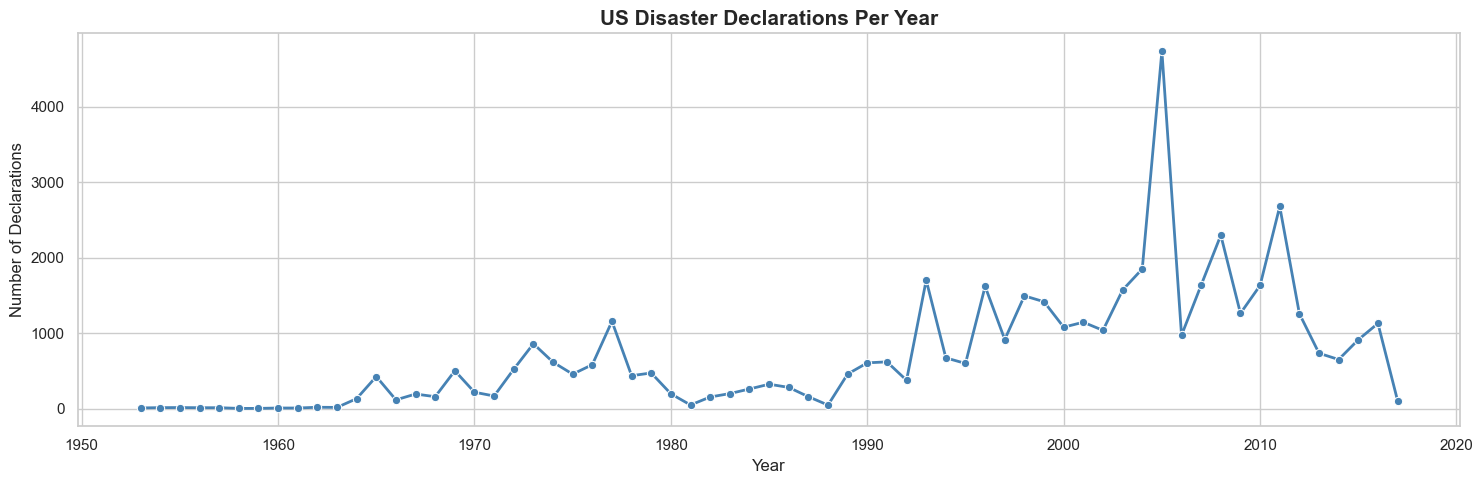

In [2]:
import os
os.makedirs('../visualizations', exist_ok=True)

yearly = df.groupby('Year').size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(15, 5))
sns.lineplot(data=yearly, x='Year', y='Count', marker='o', color='steelblue', linewidth=2, ax=ax)
ax.set_title('US Disaster Declarations Per Year', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Declarations')
plt.tight_layout()
plt.savefig('../visualizations/yearly_trend.png', dpi=150)
plt.show()


##### This line chart displays the total number of federal disaster declarations in the US per year, covering the period from 1953.

## 3. Incident Type Trends Over Time


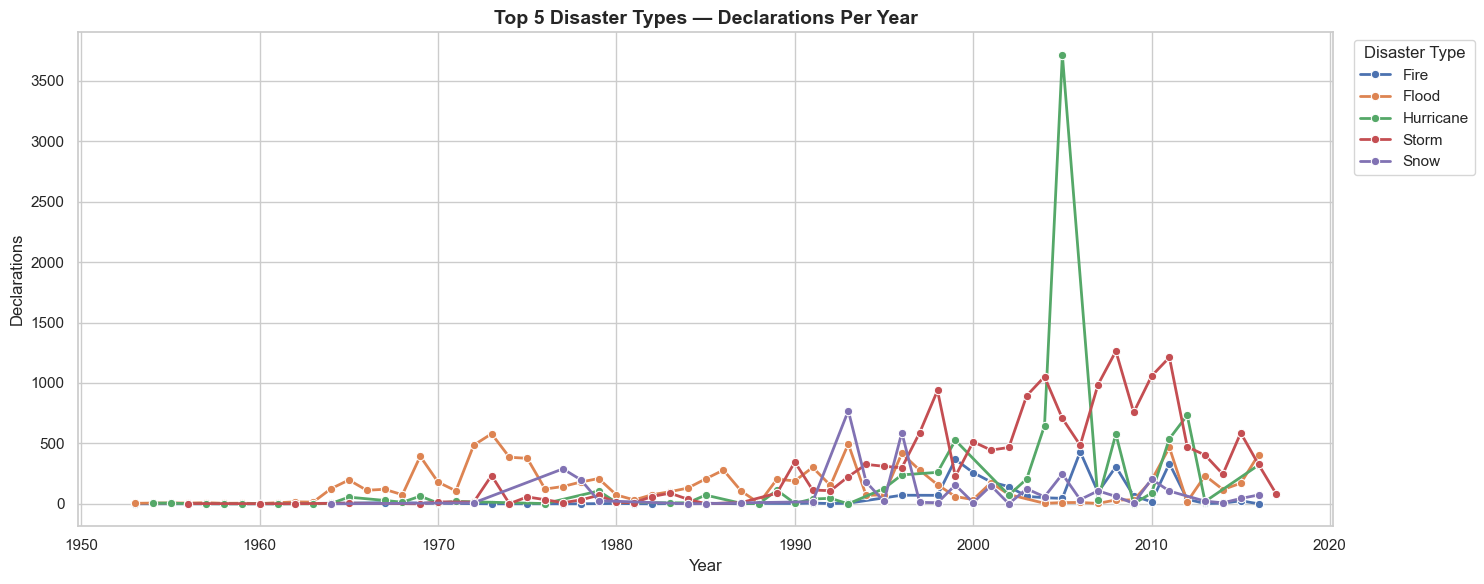

In [3]:
top5 = df['Disaster Type'].value_counts().head(5).index.tolist()
df_top5 = df[df['Disaster Type'].isin(top5)]
pivot = df_top5.groupby(['Year', 'Disaster Type']).size().reset_index(name='Count')

fig, ax = plt.subplots(figsize=(15, 6))
sns.lineplot(data=pivot, x='Year', y='Count', hue='Disaster Type',
             marker='o', linewidth=2, ax=ax)
ax.set_title('Top 5 Disaster Types — Declarations Per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Declarations')
ax.legend(title='Disaster Type', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('../visualizations/disaster_type_trends.png', dpi=150, bbox_inches='tight')
plt.show()

#### This chart tracks the frequency of different types of disasters (e.g., Fire, Flood, Severe Storms) over time to see how the "disaster mix" is changing.

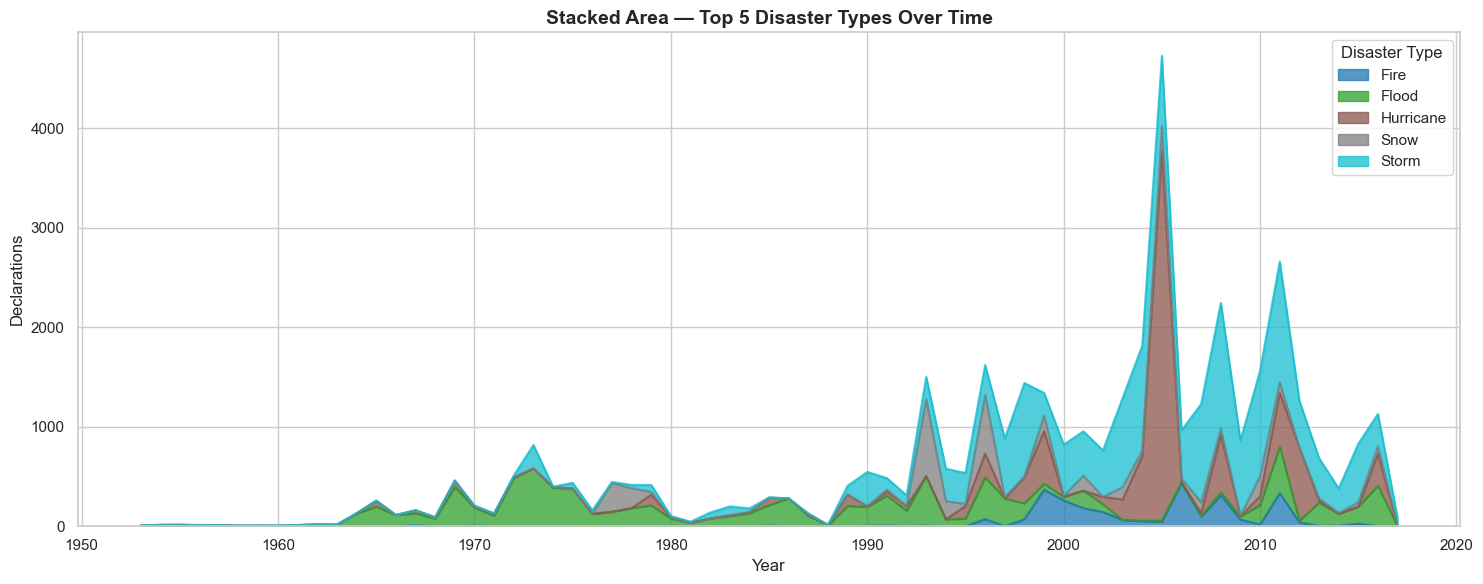

In [4]:
# Stacked area chart
pivot_wide = pivot.pivot(index='Year', columns='Disaster Type', values='Count').fillna(0)
fig, ax = plt.subplots(figsize=(15, 6))
pivot_wide.plot(kind='area', stacked=True, alpha=0.75, ax=ax, colormap='tab10')
ax.set_title('Stacked Area — Top 5 Disaster Types Over Time', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Declarations')
ax.legend(title='Disaster Type')
plt.tight_layout()
plt.savefig('../visualizations/stacked_area_disasters.png', dpi=150, bbox_inches='tight')
plt.show()

#### This chart highlights the cumulative growth of disasters, showing that the total "burden" on emergency management is expanding.

#### The "area" occupied by recent decades is much larger than the early years, proving that disaster frequency is at an all-time high.



## 4. Seasonality Analysis

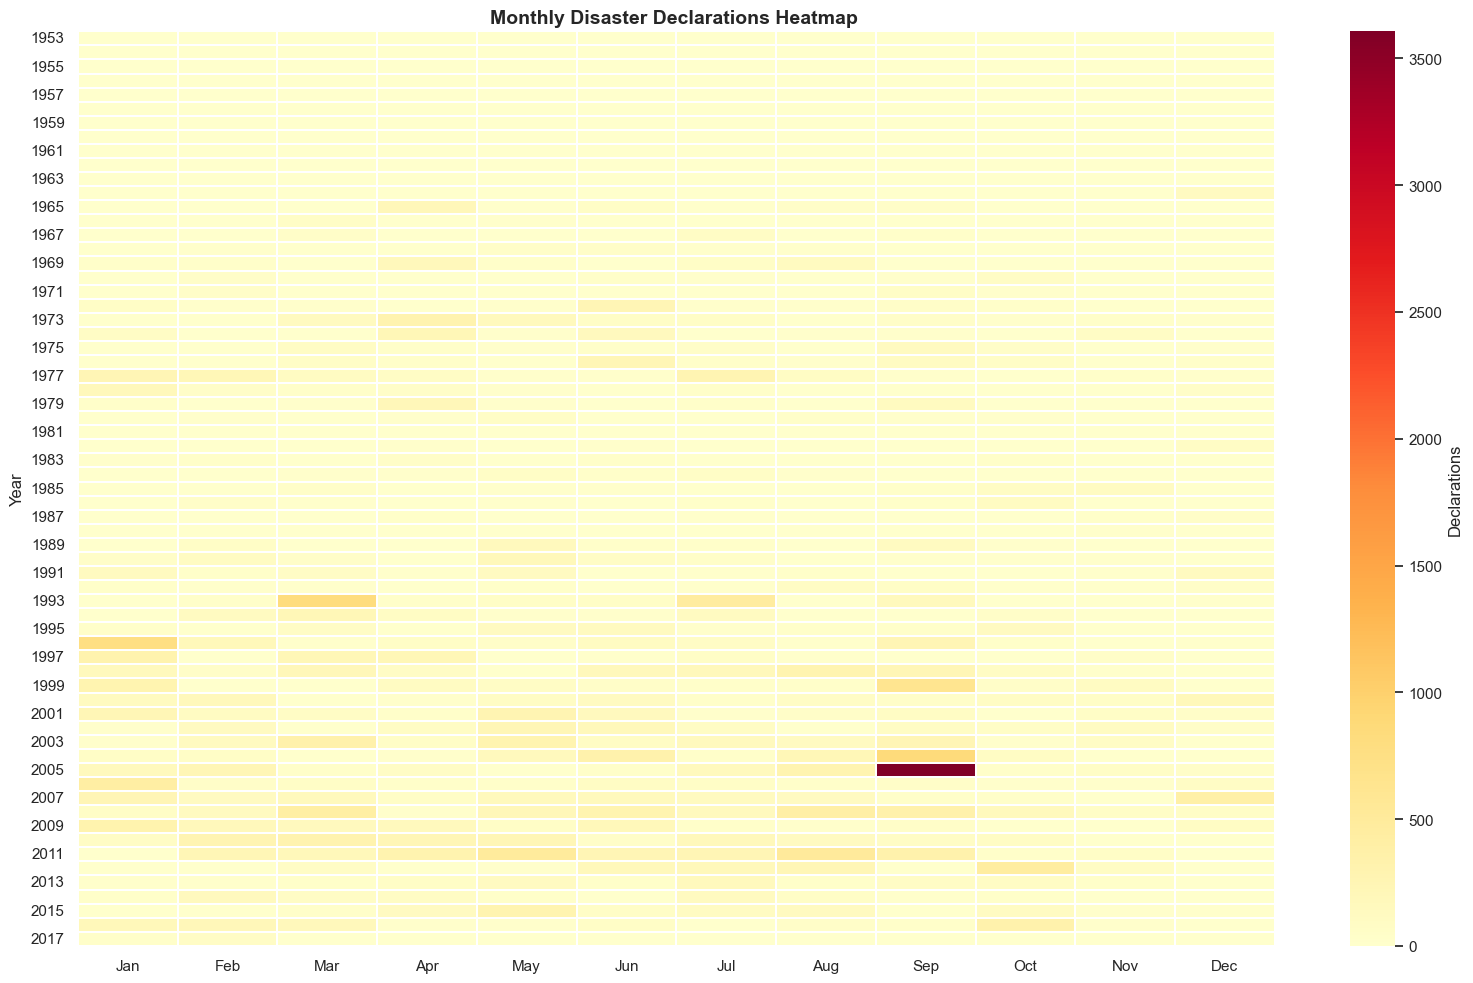

In [5]:
# Monthly Heatmap (Year × Month)
monthly_yr = df.groupby(['Year', 'Month']).size().reset_index(name='Count')
hmap = monthly_yr.pivot(index='Year', columns='Month', values='Count').fillna(0)
hmap.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(hmap, cmap='YlOrRd', linewidths=0.3, annot=False,
            cbar_kws={'label': 'Declarations'}, ax=ax)
ax.set_title('Monthly Disaster Declarations Heatmap ', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../visualizations/monthly_heatmap.png', dpi=150)
plt.show()


#### The intensity of red color in  years (bottom of the chart) confirms that disasters are becoming more frequent every month.

#### Specific horizontal bands show that certain months are consistently "hotter," proving a recurring seasonal pattern.

C:\Users\vijay\AppData\Local\Temp\ipykernel_20608\2659993433.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_order, y=season_counts.values, palette=colors, ax=ax2)


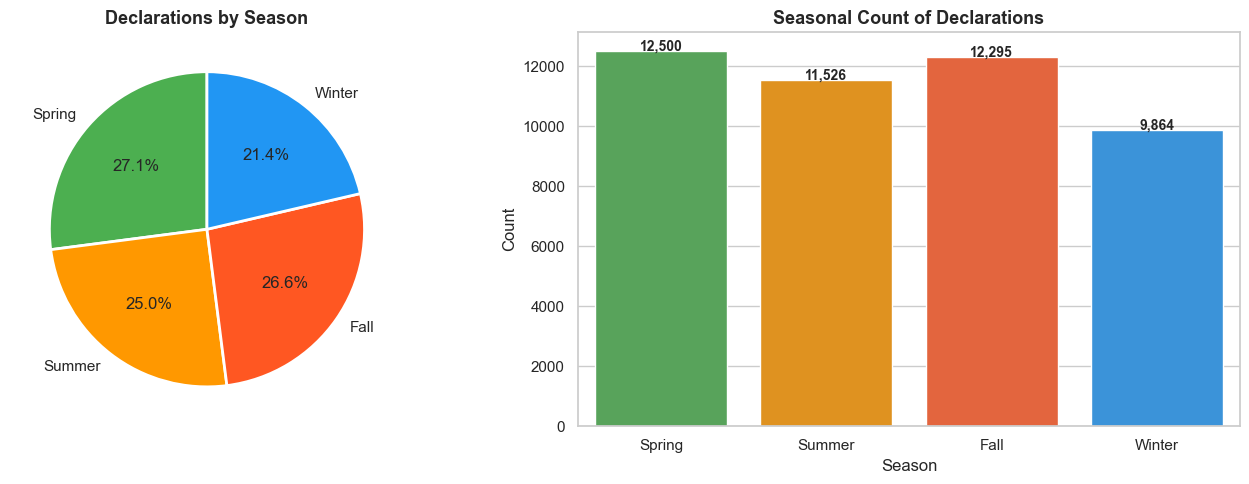

In [6]:
# Season pie + bar
season_order  = ['Spring', 'Summer', 'Fall', 'Winter']
season_counts = df['Season'].value_counts().reindex(season_order)
colors = ['#4CAF50', '#FF9800', '#FF5722', '#2196F3']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.pie(season_counts, labels=season_order, autopct='%1.1f%%',
        colors=colors, startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax1.set_title('Declarations by Season', fontsize=13, fontweight='bold')

sns.barplot(x=season_order, y=season_counts.values, palette=colors, ax=ax2)
ax2.set_title('Seasonal Count of Declarations', fontsize=13, fontweight='bold')
ax2.set_xlabel('Season')
ax2.set_ylabel('Count')
for bar, val in zip(ax2.patches, season_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{int(val):,}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../visualizations/season_distribution.png', dpi=150)
plt.show()

#### Spring is the most active season, accounting for the largest percentage of disaster declarations.

#### A bi-modal peak is identified: first in Spring (Tornadoes/Storms) and second in Late Summer (Hurricanes).

## 5. Advanced Insights

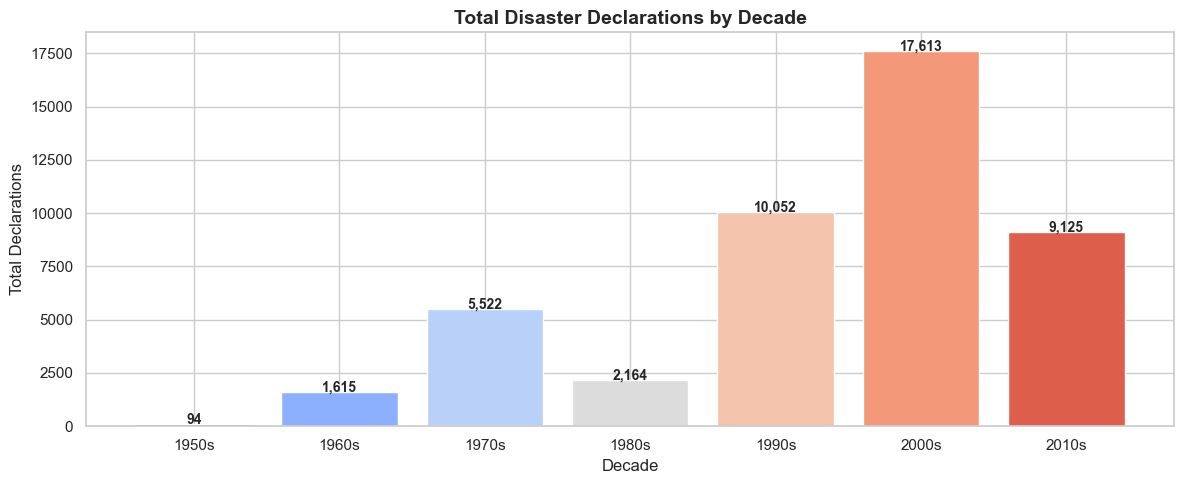

In [7]:
# Decade-level totals
decade_cnt = df.groupby('Decade').size().reset_index(name='Count')
decade_cnt['Label'] = decade_cnt['Decade'].astype(str) + 's'

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(decade_cnt['Label'], decade_cnt['Count'],
              color=sns.color_palette('coolwarm', len(decade_cnt)))
for bar, val in zip(bars, decade_cnt['Count']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,}', ha='center', fontsize=10, fontweight='bold')
ax.set_title('Total Disaster Declarations by Decade', fontsize=14, fontweight='bold')
ax.set_xlabel('Decade')
ax.set_ylabel('Total Declarations')
plt.tight_layout()
plt.savefig('../visualizations/decade_analysis.png', dpi=150)
plt.show()

The 2010s decade saw a massive jump in declarations compared to the 1950s

Every decade shows a higher count than the previous one, confirming a long-term escalation in disaster activity.

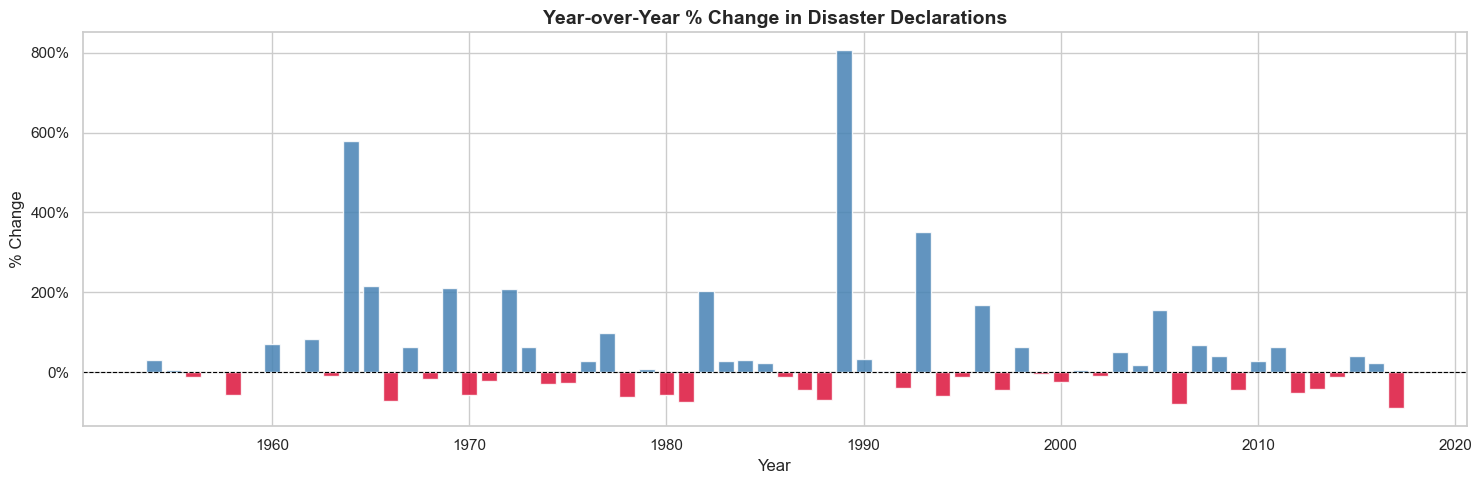

In [8]:
# Year-over-Year % Change
yearly['YoY_Pct'] = yearly['Count'].pct_change() * 100
bar_colors = ['crimson' if v < 0 else 'steelblue' for v in yearly['YoY_Pct'].fillna(0)]

fig, ax = plt.subplots(figsize=(15, 5))
ax.bar(yearly['Year'], yearly['YoY_Pct'], color=bar_colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Year-over-Year % Change in Disaster Declarations', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% Change')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
plt.tight_layout()
plt.savefig('../visualizations/yoy_change.png', dpi=150)
plt.show()

This chart measures volatility; blue bars show growth years, while red bars show decline years.
 Despite periodic declines (red bars), the frequency and magnitude of the blue "growth" spikes keep the long-term trend positive.

## 6. Summary

In [9]:
print('=' * 55)
print('      MILESTONE 2 — KEY FINDINGS SUMMARY')
print('=' * 55)
print(f" Total Records             : {len(df):,}")
print(f" Year Range                : {df['Year'].min():.0f} – {df['Year'].max():.0f}")
print(f" Peak Declaration Year     : {yearly.loc[yearly['Count'].idxmax(), 'Year']:.0f}")
print(f" Most Active Season        : {df['Season'].value_counts().idxmax()}")
print(f" Most Active Month         : {df['Month_Name'].value_counts().idxmax()}")
print(f" Most Common Disaster Type : {df['Disaster Type'].value_counts().idxmax()}")
print('=' * 55)
print(' Charts saved -> visualizations/')

      MILESTONE 2 — KEY FINDINGS SUMMARY
 Total Records             : 46,185
 Year Range                : 1953 – 2017
 Peak Declaration Year     : 2005
 Most Active Season        : Spring
 Most Active Month         : Sep
 Most Common Disaster Type : Storm
 Charts saved -> visualizations/
